# Tree–Cluster–Forest Subgroup Pipeline

This notebook runs a two-stage pipeline:

1. **Module 1 – Y-only clustering-based subgroup discovery**
   - Clusters the target variable `Y` using hierarchical clustering over many seeds.
   - Each Y-cluster is a *candidate* subgroup.
   - Candidates are scored with a size-corrected KL objective and a diversity term (SYFLOW-style).
   - The top `K` subgroups are selected.

2. **Module 2 – Random forest explanations**
   - For each selected subgroup, trains many random forests to predict subgroup membership from `X`.
   - Selects a forest that is accurate and simple (short decision paths).
   - For each subgroup, prints an explanation tree.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import export_text, plot_tree

from src.config_subgroups import TreeClusterForestConfig
from src.data_module import load_dataset
from src.cluster_subgroups import (
    discover_subgroups_by_clustering,
    build_subgroup_column,
)
from src.forest_explainer import (
    train_forest_for_subgroup,
    evaluate_forest,
)

try:
    from src.demo_utils import plot_subgroups
    HAS_PLOT_SUBGROUPS = True
except ImportError:
    HAS_PLOT_SUBGROUPS = False
    print("Warning: src.demo_utils.plot_subgroups not found; SYFLOW-style plot will use a simple fallback.")


In [ ]:
def show_explanation_tree_for_subgroup(model, feature_names, subgroup_index=None):
    """
    Show a Colab-style explanation tree for a single subgroup:
      - print the tree as text (export_text)
      - plot the tree (plot_tree)
    """
    # pick a representative tree from the forest
    best_tree = model.estimators_[0]

    # text output 
    header = (
        f"\nText tree explanation for subgroup {subgroup_index}"
        if subgroup_index is not None
        else "\nText tree explanation"
    )
    print(header)
    tree_text = export_text(best_tree, feature_names=feature_names)
    print(tree_text)

    # graphical tree
    plt.figure(figsize=(10, 6))
    plot_tree(
        best_tree,
        feature_names=feature_names,
        class_names=["not in subgroup", "in subgroup"],
        filled=True,
        rounded=True,
        fontsize=8,
    )
    if subgroup_index is not None:
        plt.title(f"Explanation tree for subgroup {subgroup_index}")
    else:
        plt.title("Explanation tree")
    plt.show()


In [ ]:
def run_pipeline_on_dataset(
    dataset_name,
    cfg,
    save_csv=True,
    output_dir="outputs_subgroups",
):
    print(f"\n=== DATASET: {dataset_name} ===")

    # ------------------------------------------------------------------
    # Load data
    # ------------------------------------------------------------------
    X, Y, feature_names, is_clf = load_dataset(dataset_name)
    n, d = X.shape
    print(f"X shape = {X.shape}, Y shape = {Y.shape}, classification={is_clf}")

    # ------------------------------------------------------------------
    # MODULE 1: clustering-based subgroup discovery
    # ------------------------------------------------------------------
    masks, rules_box, scores = discover_subgroups_by_clustering(
        X,
        Y,
        cfg,
        feature_names=feature_names,
        n_subgroups=cfg.n_subgroups,
    )

    n_subgroups_found = len(masks)
    print(f"Discovered {n_subgroups_found} subgroups.")

    if n_subgroups_found == 0:
        print("No valid subgroups found; returning early.")
        return {
            "X": X,
            "Y": Y,
            "feature_names": feature_names,
            "masks": [],
            "rules_box": [],
            "scores": [],
            "df": None,
        }

    for i, (rule, score) in enumerate(zip(rules_box, scores)):
        print(f"\n[Module 1] Subgroup {i}:")
        print(f"  score = {score:.4f}")
        print(f"  box rule = {rule}")

    # Build a single subgroup_id column for the CSV
    subgroup_id = build_subgroup_column(
        masks,
        n_samples=n,
        fill_value=-1,
    )

    df = pd.DataFrame(X, columns=feature_names)
    df["target"] = Y
    df["subgroup_id"] = subgroup_id

    if save_csv:
        os.makedirs(output_dir, exist_ok=True)
        out_path = os.path.join(output_dir, f"{dataset_name}_with_subgroups.csv")
        df.to_csv(out_path, index=False)
        print(f"\nSaved dataset with subgroup_id to: {out_path}")

    # ------------------------------------------------------------------
    # MODULE 2: Random-forest explanations
    # ------------------------------------------------------------------
    print("\n=== MODULE 2: Random-forest explanations ===")
    for k, mask in enumerate(masks):
        sg_size = int(mask.sum())
        print(f"\n--- Subgroup {k} (size={sg_size}) ---")
        model, rf_candidates = train_forest_for_subgroup(X, mask, cfg)

        if model is None:
            print("Skipping: subgroup too small to train a stable forest.")
            continue

        acc, comp = evaluate_forest(model, X, mask)
        print(f"Selected forest: accuracy={acc:.3f}, avg path length={comp:.2f}")


        show_explanation_tree_for_subgroup(model, feature_names, subgroup_index=k)

    return {
        "X": X,
        "Y": Y,
        "feature_names": feature_names,
        "masks": masks,
        "rules_box": rules_box,
        "scores": scores,
        "df": df,
    }


Datasets to process: ['california']

=== DATASET: california ===
X shape = (20640, 8), Y shape = (20640,), classification=False
Discovered 5 subgroups.

[Module 1] Subgroup 0:
  score = 1.2177
  box rule = 2 < HouseAge < 52 ∧ 1.825 < AveRooms < 141.9 ∧ 0.5 < AveBedrms < 25.64 ∧ 13 < Population < 7431 ∧ 1.275 < AveOccup < 41.21 ∧ 32.68 < Latitude < 38.91 ∧ -122.7 < Longitude < -116.4

[Module 1] Subgroup 1:
  score = 45.5328
  box rule = 0.8462 < AveRooms < 132.5 ∧ 0.4444 < AveBedrms < 34.07 ∧ 6 < Population < 3.568e+04

[Module 1] Subgroup 2:
  score = 41.2340
  box rule = 0.536 < MedInc < 15 ∧ 1.13 < AveRooms < 56.27 ∧ 0.3333 < AveBedrms < 11.41 ∧ 3 < Population < 1.612e+04 ∧ 0.75 < AveOccup < 502.5 ∧ 32.56 < Latitude < 40.63 ∧ -123.8 < Longitude < -114.6

[Module 1] Subgroup 3:
  score = 29.7014
  box rule = 0.8462 < AveRooms < 132.5 ∧ 0.4444 < AveBedrms < 34.07 ∧ 6 < Population < 3.568e+04

[Module 1] Subgroup 4:
  score = 32.1559
  box rule = 1.13 < AveRooms < 141.9 ∧ 0.3333 < AveB

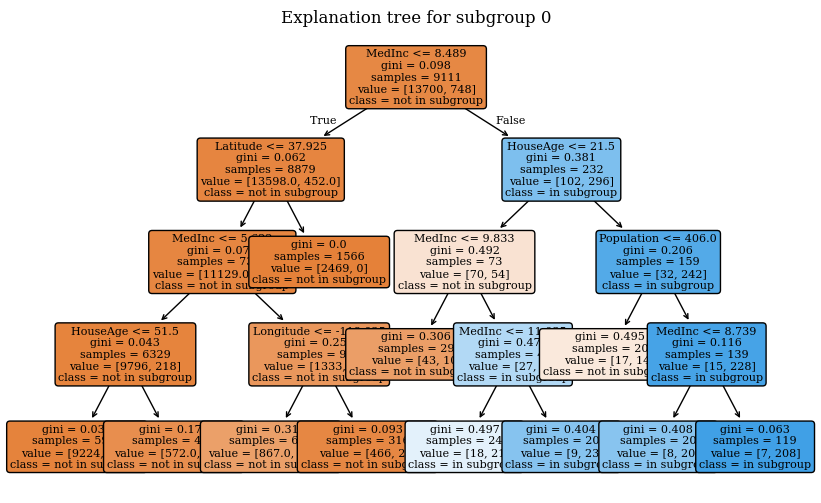


--- Subgroup 1 (size=10670) ---
Selected forest: accuracy=0.833, avg path length=4.97

Text tree explanation for subgroup 1
|--- MedInc <= 4.07
|   |--- MedInc <= 2.91
|   |   |--- MedInc <= 2.19
|   |   |   |--- AveRooms <= 3.40
|   |   |   |   |--- class: 1.0
|   |   |   |--- AveRooms >  3.40
|   |   |   |   |--- class: 1.0
|   |   |--- MedInc >  2.19
|   |   |   |--- AveOccup <= 2.05
|   |   |   |   |--- class: 0.0
|   |   |   |--- AveOccup >  2.05
|   |   |   |   |--- class: 1.0
|   |--- MedInc >  2.91
|   |   |--- AveBedrms <= 1.02
|   |   |   |--- HouseAge <= 36.50
|   |   |   |   |--- class: 1.0
|   |   |   |--- HouseAge >  36.50
|   |   |   |   |--- class: 0.0
|   |   |--- AveBedrms >  1.02
|   |   |   |--- HouseAge <= 19.50
|   |   |   |   |--- class: 1.0
|   |   |   |--- HouseAge >  19.50
|   |   |   |   |--- class: 0.0
|--- MedInc >  4.07
|   |--- MedInc <= 5.15
|   |   |--- AveRooms <= 6.04
|   |   |   |--- HouseAge <= 16.50
|   |   |   |   |--- class: 1.0
|   |   |   |---

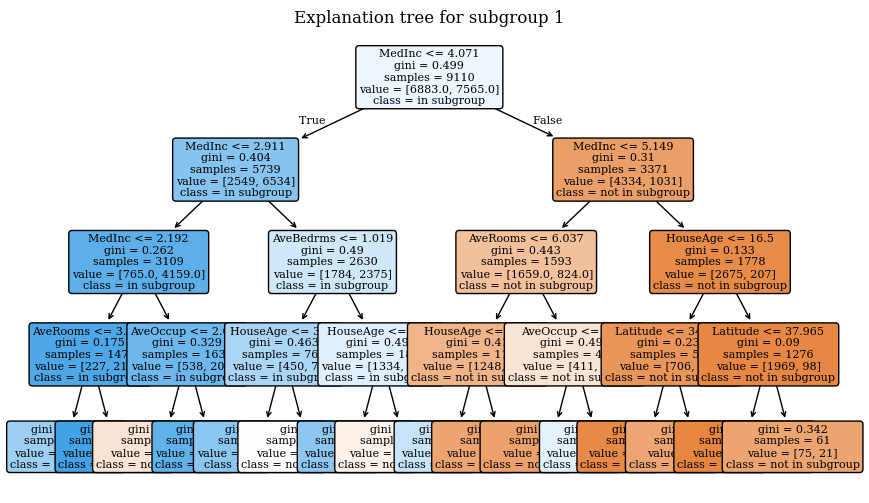


--- Subgroup 2 (size=7833) ---
Selected forest: accuracy=0.761, avg path length=4.97

Text tree explanation for subgroup 2
|--- AveOccup <= 3.54
|   |--- Latitude <= 38.49
|   |   |--- MedInc <= 3.07
|   |   |   |--- AveRooms <= 4.21
|   |   |   |   |--- class: 0.0
|   |   |   |--- AveRooms >  4.21
|   |   |   |   |--- class: 0.0
|   |   |--- MedInc >  3.07
|   |   |   |--- AveBedrms <= 1.33
|   |   |   |   |--- class: 1.0
|   |   |   |--- AveBedrms >  1.33
|   |   |   |   |--- class: 0.0
|   |--- Latitude >  38.49
|   |   |--- MedInc <= 4.13
|   |   |   |--- Longitude <= -120.03
|   |   |   |   |--- class: 0.0
|   |   |   |--- Longitude >  -120.03
|   |   |   |   |--- class: 0.0
|   |   |--- MedInc >  4.13
|   |   |   |--- AveOccup <= 2.72
|   |   |   |   |--- class: 1.0
|   |   |   |--- AveOccup >  2.72
|   |   |   |   |--- class: 0.0
|--- AveOccup >  3.54
|   |--- AveRooms <= 5.12
|   |   |--- MedInc <= 3.38
|   |   |   |--- AveRooms <= 3.08
|   |   |   |   |--- class: 0.0
|   |   

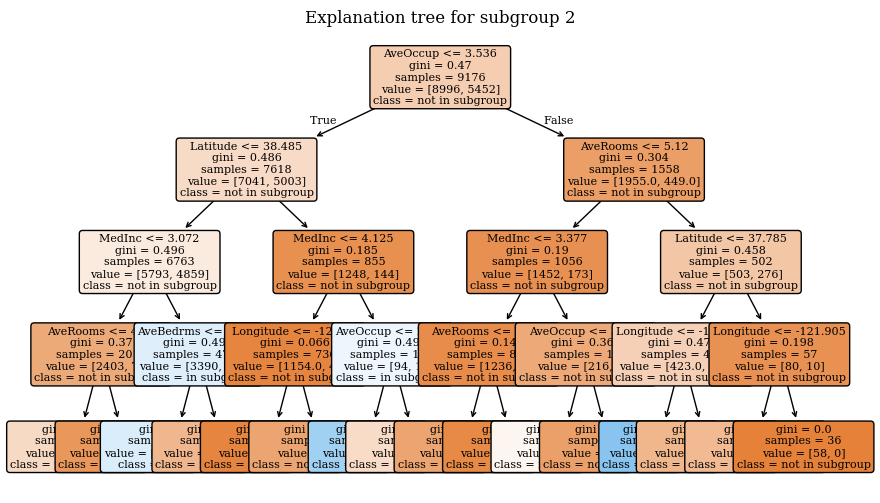


--- Subgroup 3 (size=10670) ---
Selected forest: accuracy=0.833, avg path length=4.97

Text tree explanation for subgroup 3
|--- MedInc <= 4.07
|   |--- MedInc <= 2.91
|   |   |--- MedInc <= 2.19
|   |   |   |--- AveRooms <= 3.40
|   |   |   |   |--- class: 1.0
|   |   |   |--- AveRooms >  3.40
|   |   |   |   |--- class: 1.0
|   |   |--- MedInc >  2.19
|   |   |   |--- AveOccup <= 2.05
|   |   |   |   |--- class: 0.0
|   |   |   |--- AveOccup >  2.05
|   |   |   |   |--- class: 1.0
|   |--- MedInc >  2.91
|   |   |--- AveBedrms <= 1.02
|   |   |   |--- HouseAge <= 36.50
|   |   |   |   |--- class: 1.0
|   |   |   |--- HouseAge >  36.50
|   |   |   |   |--- class: 0.0
|   |   |--- AveBedrms >  1.02
|   |   |   |--- HouseAge <= 19.50
|   |   |   |   |--- class: 1.0
|   |   |   |--- HouseAge >  19.50
|   |   |   |   |--- class: 0.0
|--- MedInc >  4.07
|   |--- MedInc <= 5.15
|   |   |--- AveRooms <= 6.04
|   |   |   |--- HouseAge <= 16.50
|   |   |   |   |--- class: 1.0
|   |   |   |---

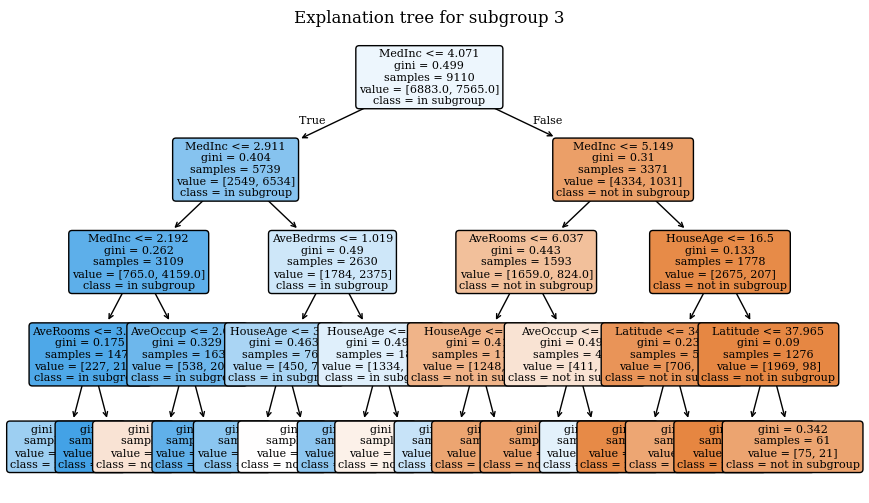


--- Subgroup 4 (size=9970) ---
Selected forest: accuracy=0.826, avg path length=4.98

Text tree explanation for subgroup 4
|--- AveOccup <= 3.44
|   |--- AveRooms <= 6.27
|   |   |--- AveOccup <= 2.34
|   |   |   |--- Latitude <= 37.95
|   |   |   |   |--- class: 1.0
|   |   |   |--- Latitude >  37.95
|   |   |   |   |--- class: 0.0
|   |   |--- AveOccup >  2.34
|   |   |   |--- Latitude <= 37.78
|   |   |   |   |--- class: 1.0
|   |   |   |--- Latitude >  37.78
|   |   |   |   |--- class: 0.0
|   |--- AveRooms >  6.27
|   |   |--- MedInc <= 4.23
|   |   |   |--- AveOccup <= 2.05
|   |   |   |   |--- class: 1.0
|   |   |   |--- AveOccup >  2.05
|   |   |   |   |--- class: 0.0
|   |   |--- MedInc >  4.23
|   |   |   |--- MedInc <= 5.26
|   |   |   |   |--- class: 1.0
|   |   |   |--- MedInc >  5.26
|   |   |   |   |--- class: 1.0
|--- AveOccup >  3.44
|   |--- Latitude <= 36.89
|   |   |--- MedInc <= 5.10
|   |   |   |--- AveOccup <= 3.64
|   |   |   |   |--- class: 0.0
|   |   |   |--

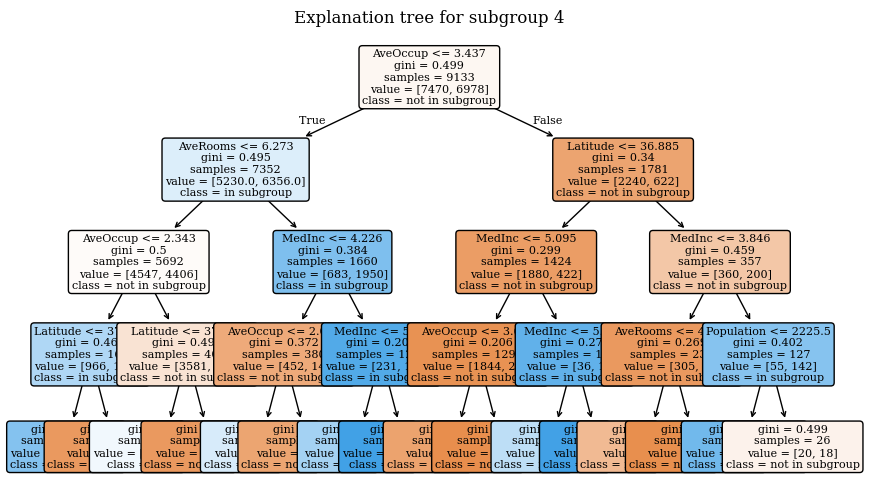

In [4]:
cfg = TreeClusterForestConfig()
print("Datasets to process:", cfg.datasets)

results = {}

for name in cfg.datasets:
    res = run_pipeline_on_dataset(name, cfg, save_csv=True, output_dir="outputs_subgroups")
    results[name] = res


SYFLOW-style target histograms for dataset 'california', subgroups [0, 1, 2]


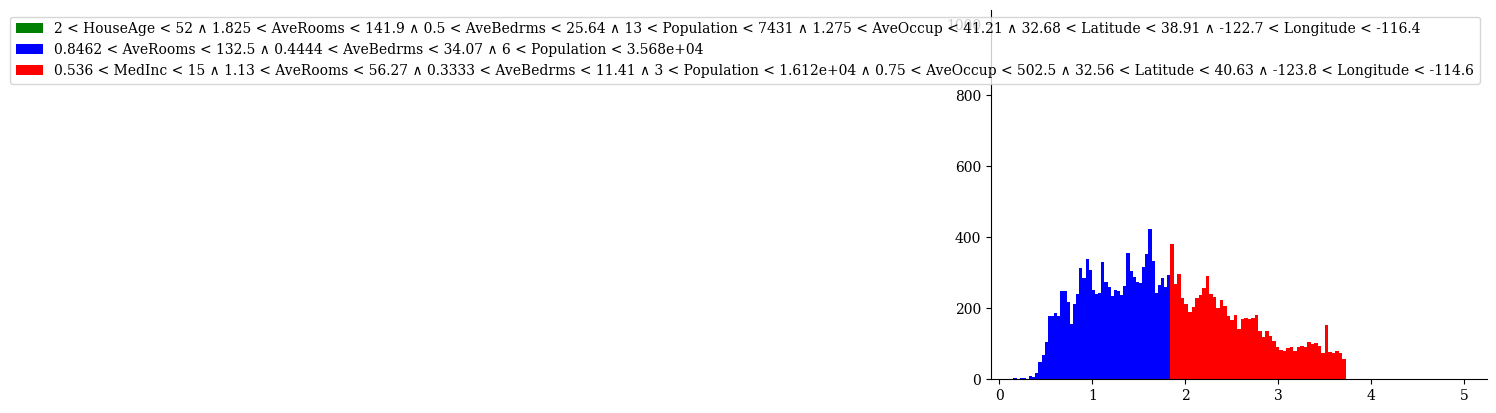

In [ ]:

dataset_name = cfg.datasets[0]
res = results[dataset_name]

X = res["X"]
Y = res["Y"]
masks = res["masks"]
rules_box = res["rules_box"]
feature_names = res["feature_names"]

if len(masks) == 0:
    print(f"No subgroups found for dataset '{dataset_name}', skipping SYFLOW-style plot.")
else:
    which_sgs = list(range(min(3, len(masks))))

    print(f"SYFLOW-style target histograms for dataset '{dataset_name}', subgroups {which_sgs}")

    if HAS_PLOT_SUBGROUPS:

        plot_subgroups(
            target=Y,
            subgroups=masks,
            rules=rules_box, 
            which_sgs=which_sgs,
        )
    else:
        plt.figure(figsize=(8, 5))
        for idx in which_sgs:
            sg = Y[masks[idx]]
            plt.hist(sg, bins=50, alpha=0.5, label=f"SG {idx}: {rules_box[idx]}")
        plt.xlabel("Target Y")
        plt.ylabel("Count")
        plt.title(f"SYFLOW-style subgroup histograms: {dataset_name}")
        plt.legend()
        plt.show()
